In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm
from os.path import join as pjoin

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)

import voxel_analysis as va
import voxel_analysis as pm
import torch_math_tools as tmt
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import surface_mapping as sfm
import load
import plot

# Load Data:
### Load Subjects [] remove this stuff

### Cifti Map to Full Arrays

In [3]:
def hemisphere_to_full(values):
    """ """
    return np.concat([values["left"], values["right"]], axis=-1)

def full_to_hemi(values):
    n_half = values.shape[-1] // 2
    return {"left": values.T[:n_half].T, "right": values.T[n_half:].T}

# Core Functional Connectivity Analysis

In [4]:
def get_cortex_data(full_data, cifti):
    pax = cifti.header.get_axis(1)
    slice_LUT = {structure: sl for structure, sl,_  in pax.iter_structures()}
    cortex_data_L = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_LEFT"]]
    cortex_data_R = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_RIGHT"]]
    return np.hstack([cortex_data_L, cortex_data_R])

In [7]:
priors_path = os.path.join(projects_path, "voxel_analysis/resources/priors.mat")

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

In [8]:
def np_corr(x, y):
    """ """
    x, y = x.T, y.T
    x_demeaned = x - x.mean(axis=1, keepdims=True)
    y_demeaned = y - y.mean(axis=1, keepdims=True)

    x_norm = x_demeaned / np.sqrt(np.sum(x_demeaned ** 2, axis=1, keepdims=True))
    y_norm = y_demeaned / np.sqrt(np.sum(y_demeaned ** 2, axis=1, keepdims=True))
    return x_norm @ y_norm.T


def torch_corr(x, y):
    """ """
    x, y = x.T, y.T
    x_demeaned = x - x.mean(axis=1, keepdims=True)
    y_demeaned = y - y.mean(axis=1, keepdims=True)

    x_norm = x_demeaned / torch.sqrt(torch.sum(x_demeaned ** 2, axis=1, keepdims=True))
    y_norm = y_demeaned / torch.sqrt(torch.sum(y_demeaned ** 2, axis=1, keepdims=True))
    return x_norm @ y_norm.T

In [9]:
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"

with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]

cached_dtseries_paths = va.utils.cache_tmp_path(dtseries_paths, write_cache=False)

Caching paths in /tmp:   0%|          | 0/54 [00:00<?, ?it/s]

In [10]:
def get_raw_core_FC(cifti_path, si):
    """ """
    cifti = nb.load(cifti_path)
    full_data = cifti.get_fdata()
    vertex_data = get_cortex_data(full_data, cifti)

    devp = dict(device="mps")
    cor = torch_corr(vertex_data[:, si], vertex_data, **devp)
    return cor

# Restart 

In [11]:
# tr_s = []
# for dtseries_path in tqdm(dtseries_paths):
#     cifti = nb.load(dtseries_path)
#     tr_s.append(cifti.shape[0])
# tr_s = np.array(tr_s)
# np.array(subject_list)[tr_s < 1_000]

# Surface Areas 

In [12]:
def get_vertex_surface_area(surface_file):
    # Load the GIFTI surface file
    gii = nb.load(surface_file)
    
    # Get the vertices and faces
    vertices = gii.darrays[0].data
    faces = gii.darrays[1].data

    # Compute surface area for each triangle
    tri_vertices = vertices[faces]
    a = tri_vertices[:, 1] - tri_vertices[:, 0]
    b = tri_vertices[:, 2] - tri_vertices[:, 0]
    cross_product = np.cross(a, b)
    triangle_areas = 0.5 * np.linalg.norm(cross_product, axis=1)

    # Distribute triangle areas to vertices
    vertex_areas = np.zeros(vertices.shape[0])
    for i in range(3):
        np.add.at(vertex_areas, faces[:, i], triangle_areas / 3)

    return vertex_areas

# Example usage:
# surface_file = "path/to/left_surface.surf.gii"
# vertex_areas = get_vertex_surface_area(surface_file)


In [65]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), example_cifti)
medial_wall_mask_L = np.isnan(medial_wall_mask_values["left"])
medial_wall_mask_R = np.isnan(medial_wall_mask_values["right"])
medial_wall_mask_64k = np.hstack([medial_wall_mask_L, medial_wall_mask_R])

Text(0.5, 1.0, 'Mean Vertex Surface Area')

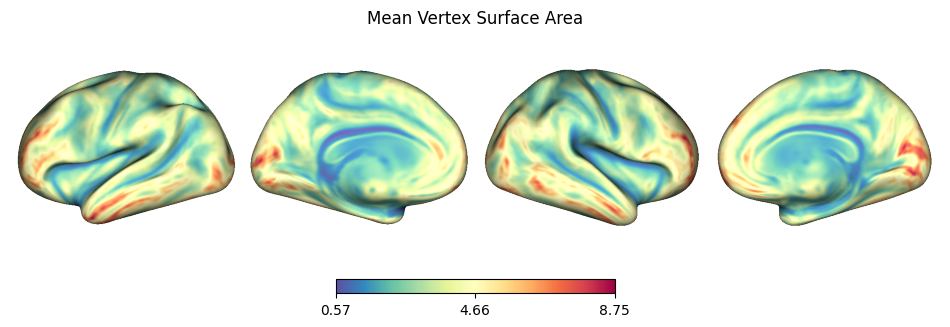

In [83]:
generic_area_file = "/data/data4/earlycort_7114/{subject}/MNINonLinear/fsaverage_LR32k/{subject}.{side}.midthickness.32k_fs_LR.area.func.gii"

all_L_area_files = [generic_area_file.format(subject=subj.split("_16")[0], side="L") for subj in subject_list]
all_R_area_files = [generic_area_file.format(subject=subj.split("_16")[0], side="R") for subj in subject_list]

L_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_L_area_files]), -1)
R_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_R_area_files]), -1)
SA_all_64k = np.concat([L_SA_all_32k, R_SA_all_32k], axis=1)
SA_all_cortex = SA_all_64k[:, ~medial_wall_mask_64k]

mean_L_SA = np.mean(L_SA_all_32k, axis=0)[:, 0]
mean_R_SA = np.mean(R_SA_all_32k, axis=0)[:, 0]

mean_SA_values = {"left": mean_L_SA, "right": mean_R_SA}
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(mean_SA_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title("Mean Vertex Surface Area")

## REsults:



### S1_D30:
    PANSS_Tot_3F - Default_Anterolateral:: R = -0.43 0.05
    PSIComposite_ScaledScore - SomatoCognitiveAction:: R = -0.44 0.03
    ProcessingSpeedIndex - SomatoCognitiveAction:: R = -0.45 0.03

### S1_D0_SubCortex
positive language

In [84]:
pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/RS_fMRI_maps"
# pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/Task_fMRI_GBU_1"


sparsity = 0.1
# mask_filter = "_D10"
mask_filter = ""
subcortex = False

subcortex_tag = "_SC" if subcortex else ""
file_tag = f"S{sparsity * 10:.0f}{mask_filter}{subcortex_tag}"
partition_paths = glob.glob(pm_dir + f"/*/*parcellation*{file_tag}.npy")
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"
print(file_tag)
with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]
len(partition_paths)

S1


54

In [85]:
S1_SC_exclude = ["ec_08_0031", "ec_08_0015", "ec_08_0006", "ec_08_0005", "ec_00_0078", "ec_00_0005"]

exclude_subjects = ["ec_00_0078", "ec_00_0005"]
exclude_subjects = []
# exclude_subjects = S1_SC_exclude

In [86]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)
example_full_vertex_data = example_cifti.get_fdata()
example_vertex_data = get_cortex_data(example_full_vertex_data, example_cifti)

In [87]:
# HC_index = pd.Series(subject_list).str.contains("_00_").values

In [88]:
# common_vertex_data = None
# n_count = 0
# for i in tqdm(np.where(HC_index)[0]):
#     subject, dtseries_path = subject_list[i], dtseries_paths[i]

#     cifti = nb.load(dtseries_path)
#     # vertex_data = get_cortex_data(cifti.get_fdata(), cifti)
#     # common_vertex_data = vertex_data if common_vertex_data is None else common_vertex_data + vertex_data
#     # n_count += 1
#     break

# # common_vertex_data = common_vertex_data / n_count
# # np.save("scratch/common_vertex_data.npy", common_vertex_data)

In [89]:
reassign = True

na_s, ns_s = [], []
valid_subjects = []
pnl_s = []

for i in tqdm(np.arange(len(subject_list))):
    subject, dtseries_path = subject_list[i], dtseries_paths[i]
    partition_path = glob.glob(pm_dir + f"/{subject}/{subject}_parcellation*{file_tag}.npy")
    assert len(partition_path) == 1

    if subject in exclude_subjects:
        continue

    partition = np.load(partition_path[0])
    if len(np.unique(partition[1])) > 10_000: # 4000
        print("skipped ", i, subject_list[i])
        continue

    networks_path = glob.glob(pm_dir + f"/{subject}/{subject}_{file_tag}_networks.npy")[0]
    corrs_path = networks_path.replace(".npy", "_corrs.npy")
    vn, vns = np.load(networks_path)

    
    # sp_corr, fc_corr = np.load(corrs_path)

    if reassign:
        # cifti = nb.load(dtseries_path)
        vertex_labels = va.na.get_partition_cortex(partition, example_cifti)
        # vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
        # remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
        
        # net_assign_index = np.argmax(sp_corr, axis=0)
        # # net_assign_index = np.argmax(fc_corr * sp_corr, axis=0)
        
        # vn = net_assign_index[remapped_vertex_labels]
        # vns = network_labels[vn]
        vn, vns, sp_corr, _ = va.na.get_network_assignment_labels(vertex_labels, example_vertex_data,
                                                         network_labels, spatial, FC)
        parcel_network_labels = np.argmax(sp_corr, axis=0)
        pnl_s.append(parcel_network_labels)
    
    na_s.append(vn)
    ns_s.append(vns)
    valid_subjects.append(subject_list[i])

  0%|          | 0/54 [00:00<?, ?it/s]

skipped  24 ec_00_0078
skipped  30 ec_08_0015


Text(0.5, 1.0, 'Example Parcel Fragments')

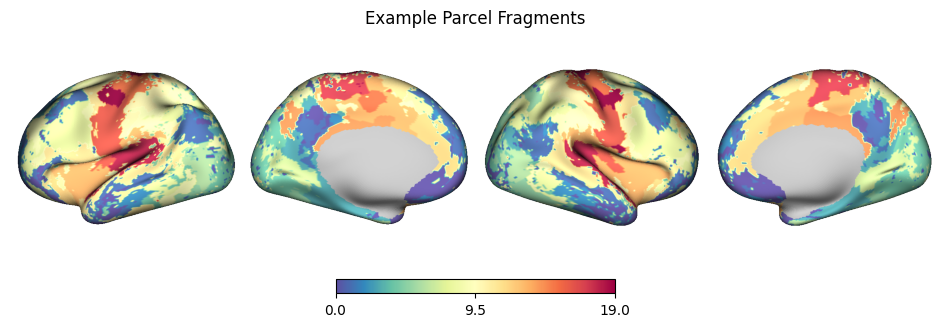

In [90]:
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(CAP_tools.utils.cifti_map(None, vn, example_cifti), cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title("Example Parcel Fragments")

In [94]:
na_s, ns_s = np.array(na_s), np.array(ns_s)
valid_subjects = np.array(valid_subjects)

szp_index = np.array(["_08_" in v for v in valid_subjects])

### Get Surface Areas 

In [125]:
valid_index = np.isin(subject_list, valid_subjects)

sizes_valid = SA_all_cortex[valid_index] * (np.expand_dims(na_s, 2) == compare_table)
size_frac_valid = sizes_valid / sizes_valid.sum(axis=(1, 2), keepdims=True)
network_sizes_valid = size_frac_valid.sum(axis=1)


# R_SA_valid = R_SA_all[valid_index]
# L_SA_valid = L_SA_all[valid_index]
# label_valid_values = CAP_tools.utils.cifti_map(None, na_s, example_cifti)
# compare_table = np.tile(np.arange(len(network_labels)), (len(valid_subjects), 1, 1))

# R_sizes_valid = R_SA_valid * (label_valid_values["right"].reshape(len(valid_subjects), -1, 1) == compare_table)
# L_sizes_valid = L_SA_valid * (label_valid_values["left"].reshape(len(valid_subjects), -1, 1) == compare_table)
# sizes_valid = R_sizes_valid + L_sizes_valid
# size_frac_valid = sizes_valid / sizes_valid.sum(axis=(1, 2), keepdims=True)

## MAke DF

In [274]:
vert_counts = np.array([(ns_s == net).mean(axis=1) for net in network_labels]).T
save_vc_df = pd.DataFrame(vert_counts, columns=network_labels)
save_vc_df["subject"] = valid_subjects
save_vc_df.to_csv('scratch/EC_vert_count_data.csv', index=False)

save_ns_df = pd.DataFrame(network_sizes_valid, columns=network_labels)
save_ns_df["subject"] = valid_subjects
save_ns_df.to_csv('scratch/EC_sizes_data.csv', index=False)

In [273]:
!realpath scratch/EC_vert_count_data.csv

/System/Volumes/Data/data/data7/network_control/projects/voxel_analysis/notebooks/scratch/EC_vert_count_data.csv


In [126]:
# vert_counts = np.array([(ns_s == net).mean(axis=1) for net in network_labels]).T
# sizes = size_frac_valid.sum(axis=1)
# plot.regplot(vert_counts.ravel(), sizes.ravel())

In [261]:
z = np.array([(ns_s == net).mean(axis=1) for net in network_labels]).T
# z = size_frac_valid.sum(axis=1)
z = network_sizes_valid

df = pd.DataFrame(z, columns=network_labels)
df["subject"] = valid_subjects
df["szp"] = np.array(["HC", "Szp"])[df["subject"].str.contains("_08_") * 1]

vsi = ~np.isin(valid_subjects, ["ec_08_0034"])
df = df.loc[vsi]

In [262]:
mdf = pd.melt(df, id_vars=["subject", "szp"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

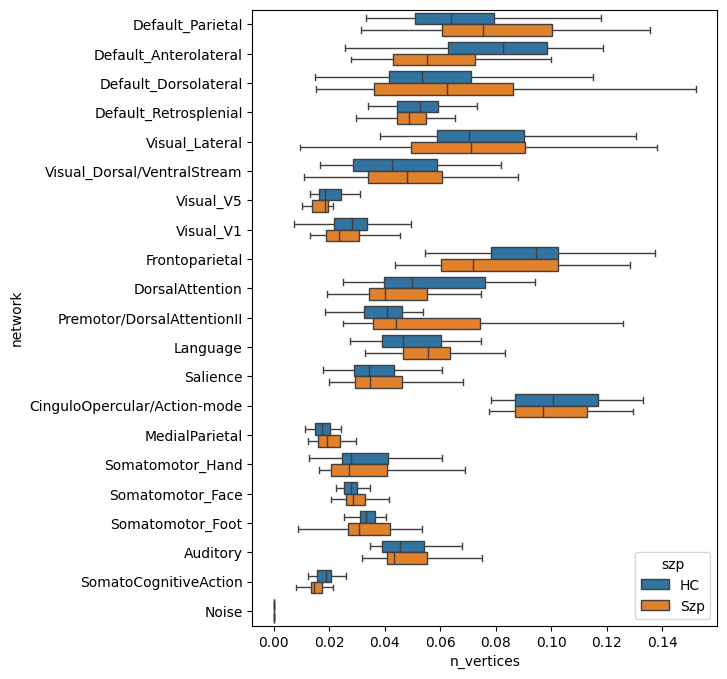

In [263]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="szp", showfliers=False, ax=ax)

In [260]:
(~szp_index).sum()

np.int64(24)

In [135]:
szp_df = df.loc[df["szp"] == "Szp"]
hc_df = df.loc[df["szp"] != "Szp"]
t_s, p_s = scipy.stats.ttest_ind(szp_df[network_labels], hc_df[network_labels])

szp_m_sizes = szp_df[network_labels].mean()
hc_m_sizes = hc_df[network_labels].mean()
size_ratio = szp_m_sizes / hc_m_sizes

sig_index = p_s < 0.05
print(network_labels[sig_index], p_s[sig_index])

for n, sr, p, in zip(network_labels, size_ratio, p_s):
    if np.isnan(p):
        continue
    print(f"size: {sr:.2f} :: p = {p:.3f} :: {n}" + "*" * ((p < 0.05) * 3))

['Default_Anterolateral' 'Language' 'SomatoCognitiveAction'] [0.01854779 0.04160989 0.02181859]
size: 1.12 :: p = 0.356 :: Default_Parietal
size: 0.79 :: p = 0.019 :: Default_Anterolateral***
size: 1.21 :: p = 0.198 :: Default_Dorsolateral
size: 0.95 :: p = 0.470 :: Default_Retrosplenial
size: 0.96 :: p = 0.716 :: Visual_Lateral
size: 1.15 :: p = 0.311 :: Visual_Dorsal/VentralStream
size: 0.80 :: p = 0.058 :: Visual_V5
size: 0.85 :: p = 0.231 :: Visual_V1
size: 0.86 :: p = 0.087 :: Frontoparietal
size: 0.84 :: p = 0.250 :: DorsalAttention
size: 1.41 :: p = 0.058 :: Premotor/DorsalAttentionII
size: 1.21 :: p = 0.042 :: Language***
size: 0.95 :: p = 0.700 :: Salience
size: 0.96 :: p = 0.473 :: CinguloOpercular/Action-mode
size: 1.28 :: p = 0.059 :: MedialParietal
size: 1.09 :: p = 0.670 :: Somatomotor_Hand
size: 1.07 :: p = 0.488 :: Somatomotor_Face
size: 0.97 :: p = 0.836 :: Somatomotor_Foot
size: 1.05 :: p = 0.622 :: Auditory
size: 0.82 :: p = 0.022 :: SomatoCognitiveAction***


### demographic correlations

In [136]:
demo_path = "/data/data7/network_control/resources/excel/GBU_tasit_demographics_all.tsv"

pdf = pd.read_csv(demo_path, sep="\t")
pdf["subject"] = pdf["PCode"]
pdf = pdf.merge(df, on="subject").reset_index(drop=True)

zpdf = pdf.query("szp == 'Szp'").reset_index(drop=True)

In [137]:
cols = ['AGE', 'Age at test', 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
       'Edinburgh score', 'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
       'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
       'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore',
       'highest grade achieved',
       'Default_Parietal', 'Default_Anterolateral', 'Default_Dorsolateral',
       'Default_Retrosplenial', 'Visual_Lateral',
       'Visual_Dorsal/VentralStream', 'Visual_V5', 'Visual_V1',
       'Frontoparietal', 'DorsalAttention', 'Premotor/DorsalAttentionII',
       'Language', 'Salience', 'CinguloOpercular/Action-mode',
       'MedialParietal', 'Somatomotor_Hand', 'Somatomotor_Face',
       'Somatomotor_Foot', 'Auditory', 'SomatoCognitiveAction', 'Noise']

cols = network_labels[sig_index]

In [138]:
dem_vars = ["AGE", 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
           'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
           'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
           'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore']

size_vars = network_labels[sig_index]
# size_vars = ["Language"]
# size_vars = [var for var in size_vars if not var in "Language"]
# size_vars = network_labels[:-1]
alpha = 0.05
print("Szp")
sig_clin_vars = []
sig_size_vars = []
for var1 in dem_vars:
    for var2 in size_vars:
        
        cdf = zpdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            sig_clin_vars.append(var1)
            sig_size_vars.append(var2)
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


print("\n\nHealthy Controls")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf.query("szp == 'HC'")[[var1, var2]].dropna() 
        if len(cdf) < 2:
            continue
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


print("\n\nAll Subjects")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")



# for var2 in size_vars:
#     print("Szp")
#     for var1 in dem_vars:
#         cdf = zpdf[[var1, var2]].dropna()        
#         r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
#         if p < alpha:
#             sig_clin_vars.append(var1)
#             sig_size_vars.append(var2)
#             s = f"{var1} - {var2}"
#             print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


#     print("\n\nHealthy Controls")
#     for var1 in dem_vars:
#         cdf = pdf.query("szp == 'HC'")[[var1, var2]].dropna() 
#         if len(cdf) < 2:
#             continue
#         r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
#         if p < alpha:
#             s = f"{var1} - {var2}"
#             print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")

#     print("\n\nAll Subjects")
#     for var1 in dem_vars:
#         cdf = pdf[[var1, var2]].dropna()        
#         r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
#         if p < alpha:
#             s = f"{var1} - {var2}"
#             print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")

Szp
PSIComposite_ScaledScore - Language:: R = -0.45 0.023
ProcessingSpeedIndex - Language    :: R = -0.45 0.025
TotalCorrect - Language            :: R = -0.41 0.038
TotalCorrect - SomatoCognitiveAction:: R = 0.47 0.015
TotalLiesCorrect - Language        :: R = -0.42 0.035
TotalLiesCorrect - SomatoCognitiveAction:: R = 0.44 0.024
TotalSarcCorrect - SomatoCognitiveAction:: R = 0.44 0.026


Healthy Controls


All Subjects
ER40_Total - Default_Anterolateral :: R = 0.34 0.027
ER40_Total_Per - Default_Anterolateral:: R = 0.30 0.048
PSIComposite_ScaledScore - Language:: R = -0.44 0.003
ProcessingSpeedIndex - Language    :: R = -0.43 0.004
TotalCorrect - Default_Anterolateral:: R = 0.33 0.025
TotalCorrect - Language            :: R = -0.40 0.006
TotalCorrect - SomatoCognitiveAction:: R = 0.44 0.002
TotalLiesCorrect - Default_Anterolateral:: R = 0.31 0.038
TotalLiesCorrect - Language        :: R = -0.30 0.043
TotalLiesCorrect - SomatoCognitiveAction:: R = 0.30 0.049
TotalSarcCorrect - Language

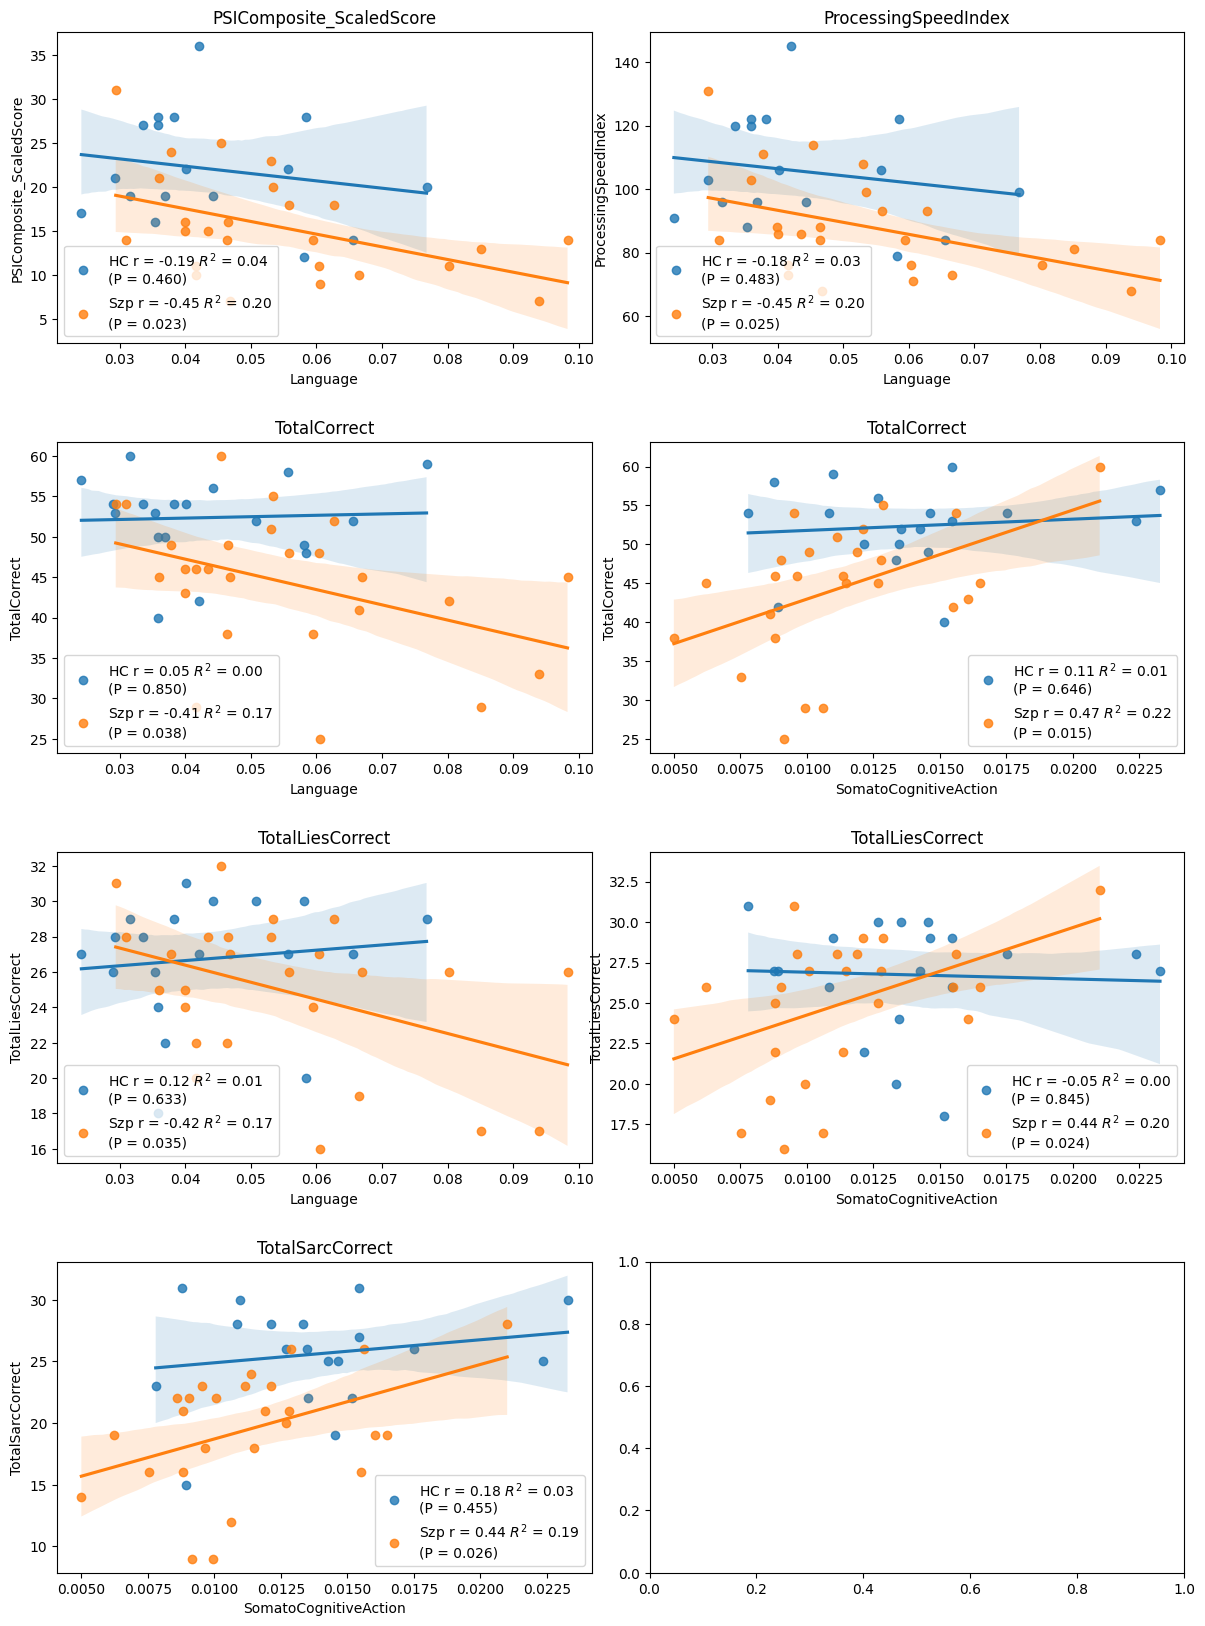

In [139]:
hc_pdf = pdf.query("szp == 'HC'")
ncols = 2
nrows = int(max(np.ceil(len(sig_clin_vars) / ncols), 1))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
fig.tight_layout(h_pad=5)
size_vars = sig_size_vars
for ax, var1, var2 in zip(axes.ravel(), sig_clin_vars, size_vars):
    if np.sum(~np.isnan(hc_pdf[var1])) > 3:
        plot.regplot(hc_pdf[var2], hc_pdf[var1], label="HC", ax=ax)
    plot.regplot(zpdf[var2], zpdf[var1], label="Szp", ax=ax)
    ax.set(title=f"{var1}")

/System/Volumes/Data/data/data7/network_control/projects/network_control/plot.py:184: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


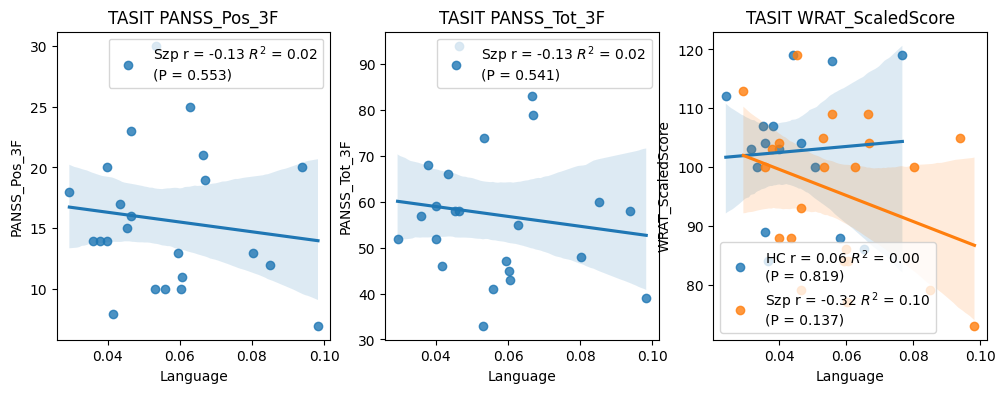

In [140]:
# clin_vars = ["TotalCorrect", "TotalLiesCorrect", "TotalSarcCorrect"]
clin_vars = ["PANSS_Pos_3F", "PANSS_Tot_3F", "WRAT_ScaledScore"]
hc_pdf = pdf.query("szp == 'HC'")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes[0]
for ax, var in zip(axes, clin_vars):
    plot.regplot(hc_pdf["Language"], hc_pdf[var], label="HC", ax=ax)
    plot.regplot(zpdf["Language"], zpdf[var], label="Szp", ax=ax)
    ax.set(title=f"TASIT {var}")

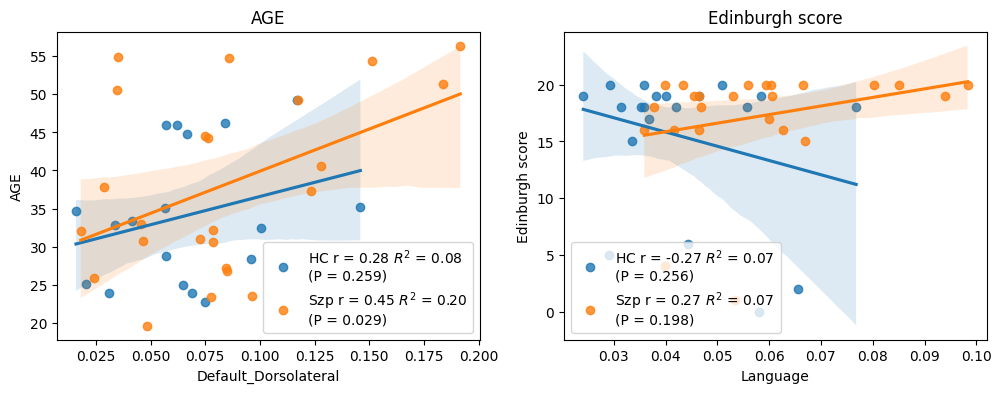

In [141]:
other_vars = ["AGE", "Edinburgh score"]
size_vars = ["Default_Dorsolateral", "Language"]
hc_pdf = pdf.query("szp == 'HC'")
fig, axes = plt.subplots(1, len(other_vars), figsize=(12, 4))
for ax, var, svar in zip(axes, other_vars, size_vars):
    plot.regplot(hc_pdf[svar], hc_pdf[var], label="HC", ax=ax)
    plot.regplot(zpdf[svar], zpdf[var], label="Szp", ax=ax)
    ax.set(title=var)

In [142]:
network_interest = "Language"
# network_interest = "MedialParietal"

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_67365/365474730.py:11: RuntimeWarning: divide by zero encountered in divide
  prob_diff = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.01, 10))
/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_67365/365474730.py:11: RuntimeWarning: invalid value encountered in divide
  prob_diff = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.01, 10))
/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_67365/365474730.py:13: RuntimeWarning: divide by zero encountered in divide
  odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.5, 2))
/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_67365/365474730.py:13: RuntimeWarning: invalid value encountered in divide
  odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.5, 2))
/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_67365/365474730.py:24: RuntimeWarning: divide by zero encountered in divide
  odds_prob = np.log2(np.clip(szp_net_prob / hc_net_pro

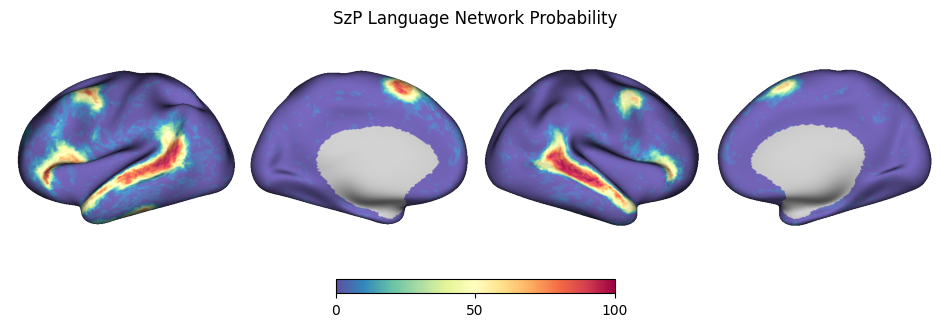

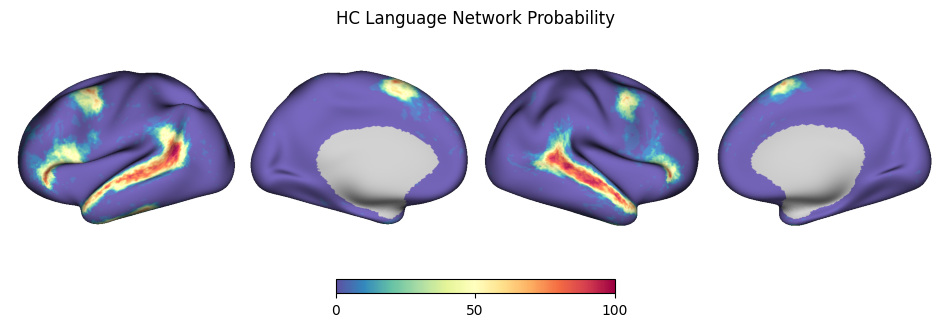

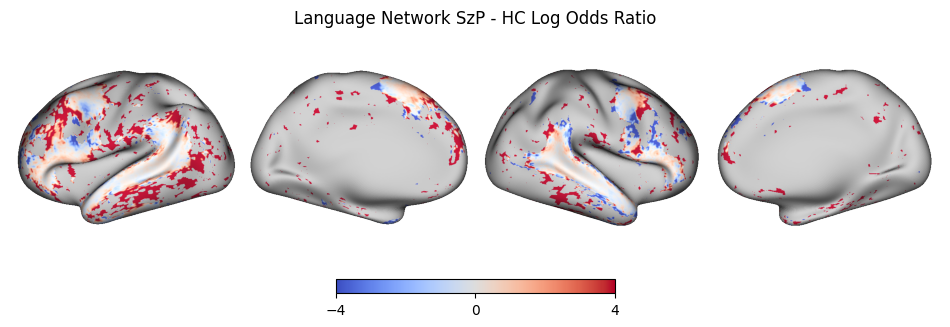

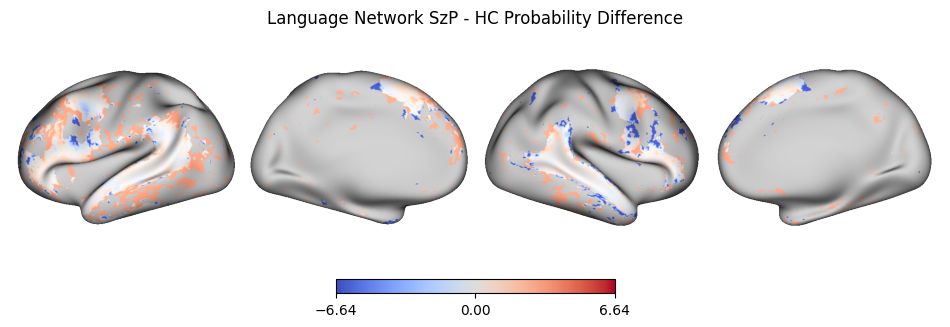

In [143]:
nl = ns_s == network_interest
szp_net_prob = nl[szp_index].mean(axis=0) * 100

szp_net_prob_values = CAP_tools.utils.cifti_map(None, szp_net_prob, example_cifti)
hc_net_prob = nl[~szp_index].mean(axis=0) * 100
hc_net_prob_values = CAP_tools.utils.cifti_map(None, hc_net_prob, example_cifti)

prob_diff = szp_net_prob - hc_net_prob
prob_diff_values = CAP_tools.utils.cifti_map(None, prob_diff, example_cifti)

prob_diff = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.01, 10))
prob_diff_values = CAP_tools.utils.cifti_map(None, prob_diff, example_cifti)
odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.5, 2))
odds_prob_values = CAP_tools.utils.cifti_map(None, odds_prob, example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(szp_net_prob_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"SzP {network_interest} Network Probability")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(hc_net_prob_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"HC {network_interest} Network Probability")

odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.125/2, 8*2))
odds_prob_values = CAP_tools.utils.cifti_map(None, odds_prob, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(odds_prob_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_interest} Network SzP - HC Log Odds Ratio")


fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(prob_diff_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_interest} Network SzP - HC Probability Difference")

sfm.write_values_to_dscalar(
    prob_diff_values,
    "/data/data7/network_control/projects/voxel_analysis/tests/outputs/ex.dscalar.nii",
    scalar_name="SzP - HC Language Network Probability"
                           )

In [144]:
prob_diff.shape

(59412,)

In [145]:
parc = sfm.Parcellation("TASIT_topo_roi131")

# Can do T-test to see regions of significantly increased language

In [146]:
nl = ns_s == network_interest
szp_net_prob = nl[szp_index].mean(axis=0) * 100
hc_net_prob = nl[~szp_index].mean(axis=0) * 100
prob_diff = szp_net_prob - hc_net_prob

In [147]:
szp_c = nl[szp_index].sum(axis=0)
hc_c = nl[~szp_index].sum(axis=0)
n_szp, n_hc = np.sum(szp_index), np.sum(~szp_index)

In [148]:
def test_language_classification(szp_counts, hc_counts, n_total_szp, n_total_hc, test="chi2"):
    results = []
    for szp, hc in zip(szp_counts, hc_counts):
        if szp == hc and hc == 0:
            results.append(("chi2", -1, 1))
            continue
        not_szp = n_total_szp - szp
        not_hc = n_total_hc - hc

        contingency_table = np.array([[szp, hc], [not_szp, not_hc]])
        
        if test == "chi2":
            chi2, p_value, _, _ = scipy.stats.chi2_contingency(contingency_table)
            results.append(("chi2", chi2, p_value))
        elif test == "fisher":
            _, p_value = fisher_exact(contingency_table)
            results.append(("fisher", None, p_value))
        else:
            raise ValueError("Invalid test type. Choose 'chi2' or 'fisher'.")

    return results


In [149]:
szp_roi_counts = [CAP_tools.utils.cifti_map(None, nl[szp_index][i], example_cifti) for i in range(n_szp)]
szp_roi_counts = np.array([parc.map_to_ROI(z_i)["value"] for z_i in szp_roi_counts])

hc_roi_counts = [CAP_tools.utils.cifti_map(None, nl[~szp_index][i], example_cifti) for i in range(n_hc)]
hc_roi_counts = np.array([parc.map_to_ROI(z_i)["value"] for z_i in hc_roi_counts])
nodes = parc.map_to_ROI(szp_net_prob_values)["node"]

In [150]:
szp_rois = parc.map_to_ROI(szp_net_prob_values)
hc_rois = parc.map_to_ROI(hc_net_prob_values)

both_rois = szp_rois.merge(hc_rois, on="node")

In [151]:
thres = 5
ORs = both_rois["value_x"] / (both_rois["value_y"] + (both_rois["value_y"] < thres) * 100)

# ORs[(both_rois["value_y"] == 0)] = np.nan
ORs[both_rois["value_y"] < thres] = np.nan
both_rois["ORs"] = ORs
both_rois = both_rois.sort_values("ORs", ascending=False)

In [152]:
n_szp, n_hc = np.sum(szp_index), np.sum(~szp_index)

szp_c = both_rois["value_x"]

In [153]:
def statistic(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

def safe_odds_ratio(x, y, axis):
    ym = np.mean(y, axis=axis)
    return np.mean(x, axis=axis) / (ym + (ym < 0.05) * 100)

In [154]:
res = scipy.stats.permutation_test((szp_roi_counts, hc_roi_counts), safe_odds_ratio, vectorized=True,
                                   n_resamples=10_000, alternative="greater")
stat_s, p_s = res.statistic, res.pvalue
q_s = scipy.stats.false_discovery_control(p_s)

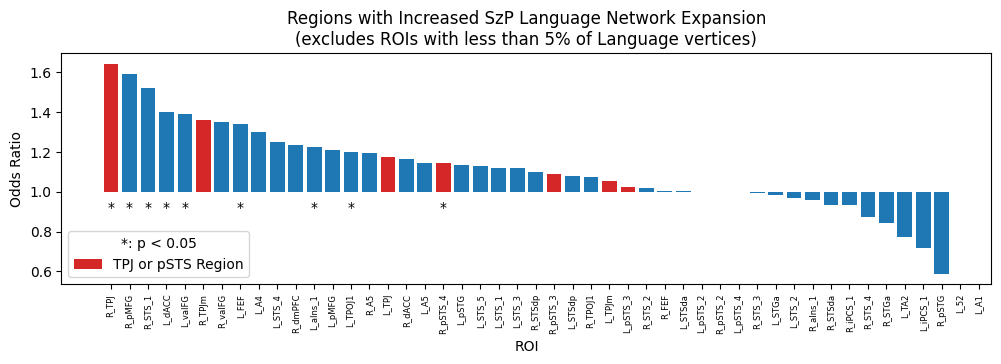

In [155]:
c = np.array(["C3" if any(tok in v.lower() for tok in ["tpj", "psts"])else "C0" for v in both_rois["node"]])

fig, ax = plt.subplots(figsize=(12, 3))
plt.bar(both_rois["node"], both_rois["ORs"] - 1, bottom=1, color=c)
plt.xticks(fontsize=6, color='black', rotation=90);
ax.legend(["TPJ or pSTS Region"], title="*: p < 0.05")
# ax.set_ylim(0.7, 3)
ax.set(xlabel="ROI", ylabel="Odds Ratio",
       title=f"Regions with Increased SzP {network_interest} Network Expansion"
       f"\n(excludes ROIs with less than 5% of {network_interest} vertices)")

for node in nodes[p_s < 0.05].values:
    v = np.isnan(both_rois.query(f"node == '{node}'")["ORs"]).values[0]
    if not v:
        ax.text(node, 0.9, "*", ha="center", label="p < 0.05")


In [156]:
# test_language_classification(szp_rois[], hc_c, n_szp, n_hc)test_language_classification(szp_c, hc_c, n_szp, n_hc)

In [157]:
topo_roi_values = {}
for lab in sorted(parc.rh_label_indices.keys()):
    if lab == "???":
        continue
    ind = parc.rh_label_indices[lab]
    
    topo_roi_values[lab] = np.mean(prob_diff_values["right"][ind])


# for lab in sorted(parc.lh_label_indices.keys()):
#     if lab == "???":
#         continue
#     ind = parc.lh_label_indices[lab]
#     topo_roi_values[lab] = np.nanmean(prob_diff_values["left"][ind])

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


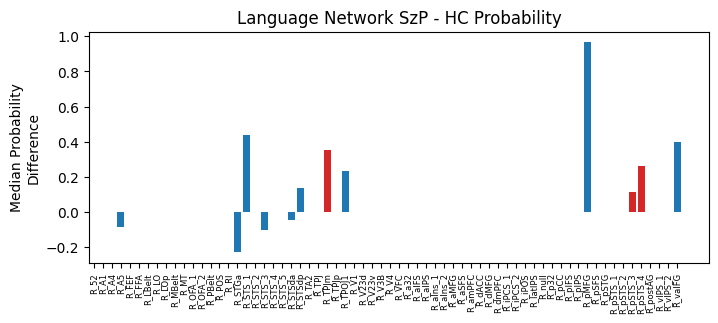

In [158]:
c = np.array(["C3" if "tpj" in v.lower() or "psts" in v.lower() else "C0" for v in topo_roi_values.keys()])
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(topo_roi_values.keys(), topo_roi_values.values(), color=c)
ax.set(ylabel="Median Probability\nDifference", title=f"{network_interest} Network SzP - HC Probability")
plt.xticks(fontsize=6, color='black', rotation=90);

In [159]:
r_tpj_labels = parc.subset_labels(["R_TPJ", "L_TPJ"])

# Functional Connectivity Analysis 

In [160]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def load_partition_labels(partition_path, template_cifti):
    """ """
    partition = np.load(partition_path)
    vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
    vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
    remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
    return remapped_vertex_labels

def load_network_labels(network_path):
    return np.load(network_save_path)[0].astype(int)

def safe_mean(arr, **kwargs):
    # if arr.ndim == 1 and len(arr) == 0:
    #     return np.nan
    return np.mean(arr, **kwargs)


def calculate_mean_ROI_fc(sc_cortex, vertex_labels, only_nonzero=True, partial_nonzero=True):
    """ """
    unl = np.sort(np.unique(vertex_labels))
    if only_nonzero:
        mean_parcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label].data) for label in unl])
        mean_intraparcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label][:, vertex_labels == label].data) for label in unl])
    elif partial_nonzero:
        parcel_fc_z = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_z])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[(parcel_fc > 0) & (vertex_labels == label)])
                                        for label, parcel_fc in zip(unl, parcel_fc_z)])
    else:
        parcel_fc = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc) for parcel_fc in parcel_fc])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[:, vertex_labels == label]) for label, parcel_fc in zip(unl, parcel_fc)])

    return mean_parcel_fc, mean_intraparcel_fc

def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)


def make_parcel_network_map(pni, vni):
    dz = {}
    for p, v in zip(pni, vni):
        assert dz.get(p, v) == v
        dz[p] = v
        # if p in dz:
        #     assert dz[p] == v
        # else:
        #     dz[p] = v
    dt = {v: np.array(dz[v]) for v in set(vni)}
    return np.array([dz[p] for p in sorted(dz.keys())])

### Look at decreased connectivity

    [] Can also look at relative decreased connectivity, i.e. relative to oneself
    [] using network priors comparing vertex level do we see decreased FC?

In [295]:
template_cifti = example_cifti

network_df = []

mip_s = []

valid_index = -1
for i in tqdm(np.arange(len(subject_list))):
    subject, dtseries_path = subject_list[i], dtseries_paths[i]
    if subject not in valid_subjects:
        continue

    valid_index += 1
    partition_path = pm_dir + f"/{subject}/{subject}_parcellation_{file_tag}.npy"
    FC_path = pm_dir + f"/{subject}/{subject}_voxel_FC_{file_tag}.npz"

    vni = na_s[valid_index]
    # parcel_network_labels = pnl_s[valid_index]
    
    
    sc_cortex = load_FC_cortex(FC_path, template_cifti)

    # sc_cortex.data[sc_cortex.data <= 0.7] = 0
    # sc_cortex.eliminate_zeros()
    
    pni = load_partition_labels(partition_path, template_cifti)
    parcel_network_map = make_parcel_network_map(pni, vni)
    # print(len(parcel_network_map), pni.max())
    assert pni.max() + 1 == len(parcel_network_map)
    
    mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, pni, only_nonzero=True)

    
    
    nnz_row = (sc_cortex > 0).sum(axis=0)
    mean_FC_i = np.array(sc_cortex.sum(axis=0) / (nnz_row + (nnz_row == 0))).ravel()
    # mip_s.append(mean_FC_i)
    mip_s.append(mean_intraparcel_fc_nz[pni])  # This might look the best?
    
    mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)
    
    parcel_net_map_index_set = parcel_network_map.reshape(-1, 1) == np.arange(np.max(parcel_network_map) + 1)
    mean_network_parcel_level_fc_nz = np.array([np.nanmean(mean_parcel_fc_nz[ind]) for ind in parcel_net_map_index_set.T])
    mean_network_intraparcel_level_fc_nz = np.array([np.nanmean(mean_intraparcel_fc_nz[ind]) for ind in parcel_net_map_index_set.T])
    
    # network_df.append([mean_network_fc_nz, mean_intranetwork_fc_nz])
    network_df.append([mean_intranetwork_fc_nz])  ## Language P = 0.03
    # network_df.append([mean_network_fc_nz])  ## Language P = 0.04
    # network_df.append([mean_network_intraparcel_level_fc_nz])  ## Garbage as weird bug
mip_s = np.array(mip_s)

  0%|          | 0/54 [00:00<?, ?it/s]

In [296]:
t_s, p_s = scipy.stats.ttest_ind(mip_s[szp_index], mip_s[~szp_index])
q_s = np.full(len(p_s), fill_value=np.nan)
q_s[~np.isnan(p_s)] = scipy.stats.false_discovery_control(p_s[~np.isnan(p_s)])

t_s_masked = t_s.copy()
t_s_masked[p_s >= 0.05] = np.nan

(<Axes: >, <surfplot.plotting.Plot at 0x31c5d6dd0>)

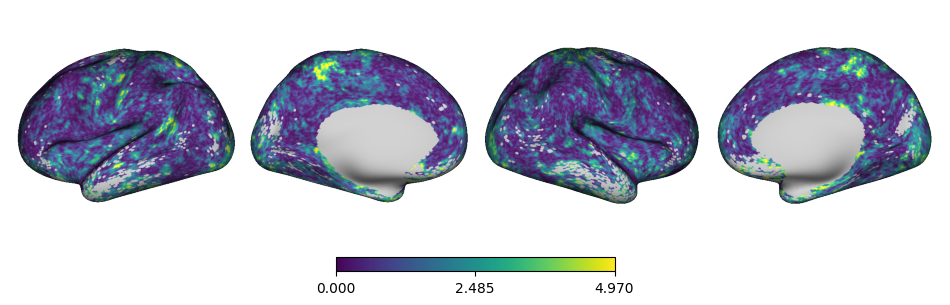

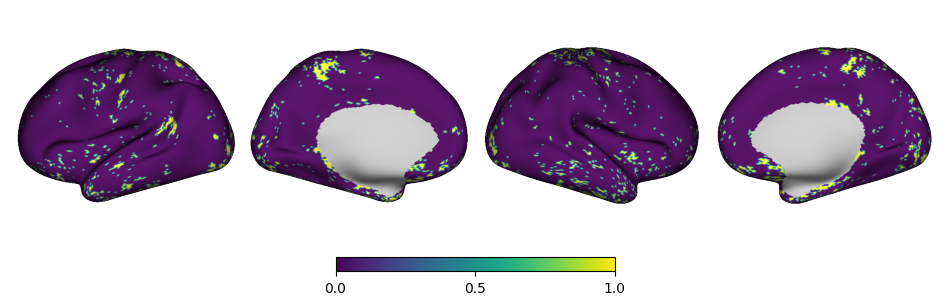

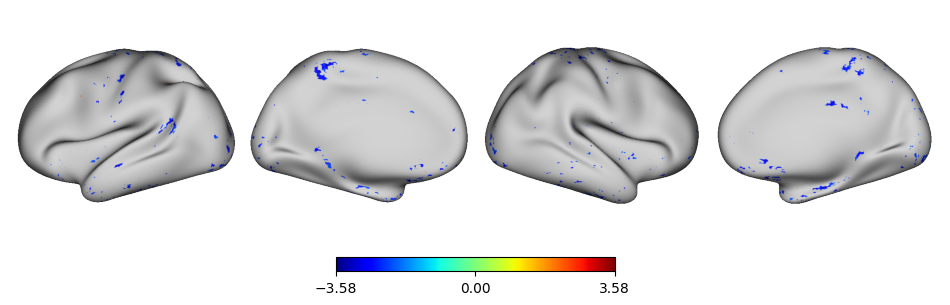

In [297]:
vertex_plot(-np.log(p_s), template_cifti, cmap=plt.cm.viridis, pclip=(None, 99))
vertex_plot((p_s < 0.05) * 1, template_cifti, cmap=plt.cm.viridis)
vertex_plot(t_s_masked, template_cifti, cmap=plt.cm.jet, pclip=(1, 99))

In [244]:
# ndf = pd.DataFrame(np.vstack(network_df) / np.vstack(network_df).sum(axis=1, keepdims=True), columns=network_labels[:-1])
ndf = pd.DataFrame(np.vstack(network_df), columns=network_labels[:-1])
ndf["subject"] = valid_subjects
ndf["szp"] = np.array(["HC", "Szp"])[ndf["subject"].str.contains("_08_") * 1]

In [245]:
melted_ndf = pd.melt(ndf, id_vars=["subject", "szp"], var_name="network", value_name="FC")

<Axes: xlabel='FC', ylabel='network'>

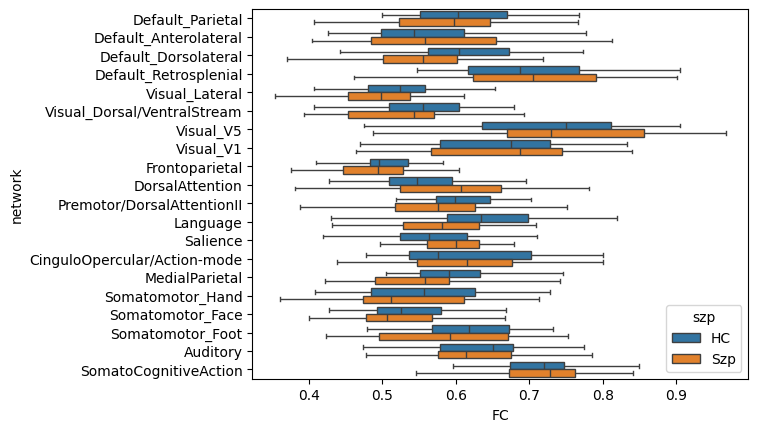

In [246]:
sns.boxplot(data=melted_ndf, x="FC", y="network", hue="szp", showfliers=False)

In [257]:
szp_df = ndf.loc[ndf["szp"] == "Szp"]
hc_df = ndf.loc[ndf["szp"] != "Szp"]
t_s, p_s = scipy.stats.ttest_ind(szp_df[network_labels[:-1]], hc_df[network_labels[:-1]])

sig_index = p_s < 0.05
for n, sr, p in zip(network_labels[:-1][sig_index], FC_ratio[sig_index], p_s[sig_index]):
    if np.isnan(p):
        continue
    print(f"FC: {sr:.2f} :: p = {p:.3f} :: {n}" + "*" * ((p < 0.05) * 3))
print()
print(network_labels[:-1][sig_index], p_s[sig_index])



szp_m_FCs = szp_df[network_labels[:-1]].mean()
hc_m_FCs = hc_df[network_labels[:-1]].mean()
FC_ratio = szp_m_FCs / hc_m_FCs

for n, sr, p, in zip(network_labels[:-1], FC_ratio, p_s):
    if np.isnan(p):
        continue
    print(f"FC: {sr:.2f} :: p = {p:.3f} :: {n}" + "*" * ((p < 0.05) * 3))

FC: 0.90 :: p = 0.023 :: Default_Dorsolateral***
FC: 0.92 :: p = 0.030 :: Language***
FC: 0.93 :: p = 0.046 :: MedialParietal***

['Default_Dorsolateral' 'Language' 'MedialParietal'] [0.02334566 0.03007355 0.04646858]
FC: 0.98 :: p = 0.678 :: Default_Parietal
FC: 1.01 :: p = 0.913 :: Default_Anterolateral
FC: 0.90 :: p = 0.023 :: Default_Dorsolateral***
FC: 1.00 :: p = 0.944 :: Default_Retrosplenial
FC: 0.95 :: p = 0.177 :: Visual_Lateral
FC: 0.95 :: p = 0.168 :: Visual_Dorsal/VentralStream
FC: 1.02 :: p = 0.636 :: Visual_V5
FC: 1.08 :: p = 0.822 :: Visual_V1
FC: 1.00 :: p = 0.945 :: Frontoparietal
FC: 1.08 :: p = 0.243 :: DorsalAttention
FC: 0.94 :: p = 0.147 :: Premotor/DorsalAttentionII
FC: 0.92 :: p = 0.030 :: Language***
FC: 1.03 :: p = 0.425 :: Salience
FC: 0.99 :: p = 0.729 :: CinguloOpercular/Action-mode
FC: 0.93 :: p = 0.046 :: MedialParietal***
FC: 0.96 :: p = 0.371 :: Somatomotor_Hand
FC: 0.98 :: p = 0.646 :: Somatomotor_Face
FC: 0.96 :: p = 0.307 :: Somatomotor_Foot
FC: 0.9

In [248]:
pdf = pd.read_csv(demo_path, sep="\t")
pdf["subject"] = pdf["PCode"]
npdf = pdf.merge(ndf, on="subject").reset_index(drop=True)
znpdf = npdf.query("szp == 'Szp'").reset_index(drop=True)

In [249]:
dem_vars = ["AGE", 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
           'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
           'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
           'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore']

size_vars = network_labels[:-1][sig_index]
size_vars = ["Language"]
# size_vars = [var for var in size_vars if not var in "Language"]
# size_vars = network_labels[:-1]
alpha = 0.1
print("Szp")
sig_clin_vars = []
sig_size_vars = []
for var1 in dem_vars:
    for var2 in size_vars:
        
        cdf = znpdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            sig_clin_vars.append(var1)
            sig_size_vars.append(var2)
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


print("\n\nHealthy Controls")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = npdf.query("szp == 'HC'")[[var1, var2]].dropna() 
        if len(cdf) < 2:
            continue
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


print("\n\nAll Subjects")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = npdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.3f}")


Szp
Gender - Language                  :: R = -0.43 0.031


Healthy Controls
Participant SES - Language         :: R = -0.40 0.069


All Subjects
PSIComposite_ScaledScore - Language:: R = 0.26 0.098


### PM Sizes differences
[] surface maps of expansion and contraction between szp vs hc
[] quantify stability: variable rs times, using HCP, etc

In [65]:
spatial_values_i = CAP_tools.utils.cifti_map(None, vertex_networks, example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[sp_index]} Spatial Probability")

NameError: name 'vertex_networks' is not defined

Text(0.5, 1.0, 'Visual_Dorsal/VentralStream Spatial Probability')

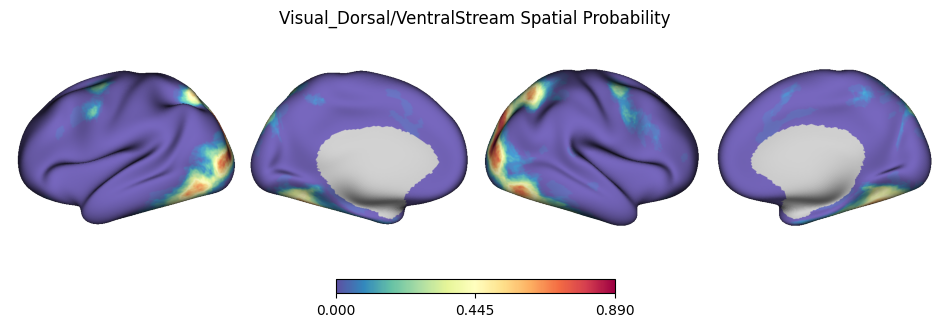

In [265]:
spatial_values_i = CAP_tools.utils.cifti_map(None, spatial[sp_index], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[sp_index]} Spatial Probability")


# Load infomaps Parcellations

In [90]:
sparsity = 0.1
dist_threshold = 10
subcortex = True
prefix = "example"

In [91]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

In [92]:
outputs_path = "/data/data7/network_control/projects/voxel_analysis/tests/outputs/"

subcortex_tag = "_SC" if subcortex else ""
param_tag = f"S{sparsity * 10:.0f}_D{dist_threshold}{subcortex_tag}"
partition_path = os.path.join(outputs_path, f"{prefix}_parcellation_{param_tag}.npy")

In [95]:
def process_partition(partition, cifti, min_voxels=0, n_vertices=91_282, filter_subcortex=True):
    """ """
    index, groups = partition
    # if filter_subcortex:
    #     subcortex_index = index >= (32_492 * 2)
    #     index, groups = index[~subcortex_index], np.unique(groups[~subcortex_index], return_inverse=True)[1]

    groups = np.random.permutation(np.max(groups))[groups - 1]    
    unique_groups, counts = np.unique(groups, return_counts=True)
    count_filter = np.isin(groups, unique_groups[counts >= min_voxels])
    
    vertex_labels = np.full(n_vertices, fill_value=np.nan)
    vertex_labels[index] = groups
    # vertex_labels[index[count_filter]] = groups[count_filter]
    
    precision_map_values = CAP_tools.utils.cifti_map(None, vertex_labels, cifti)
    # precision_map_values = CAP_tools.utils.cifti_map(index, groups, cifti)
    return precision_map_values, (index, groups)

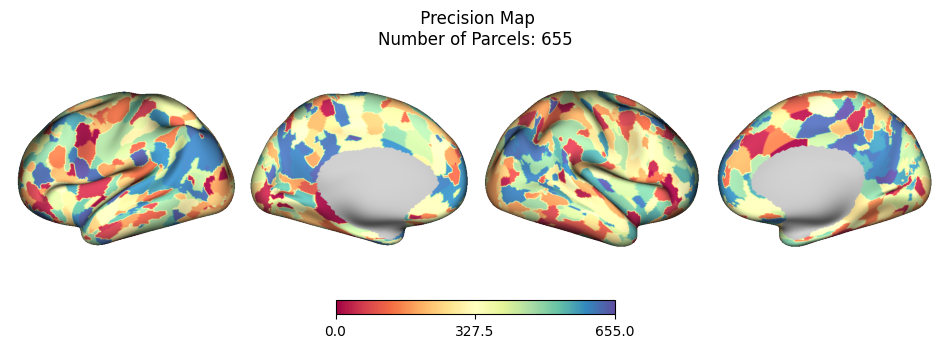

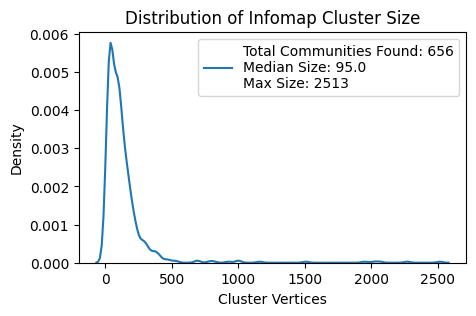

In [96]:
partition = np.load(partition_path)
precision_map_values, partition = process_partition(partition, example_cifti)

va.pm.plot_precision_map(precision_map_values)
va.pm.precision_map_QC_plots(partition)
# va.pm.write_dlabel_precision_map(precision_map_values, dlabel_path, label="example_precision_map")

# Distance and Subcortical Masking

In [69]:
sfm.get_cortex_mask(rs_dtseries)

array([ True,  True,  True, ..., False, False, False])

In [70]:
dist_dir = "/data/data7/network_control/projects/network_control/resources/brain_distances"
ex_dist_txt_path = os.path.join(dist_dir, "Schaefer400_geodesic_distmat_R.txt")
ex_dist_txt_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

geodesic_distmat_L_path = os.path.join(dist_dir, "dense_geodesic_distmat_L.txt")
geodesic_distmat_R_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

In [90]:
from scipy.sparse import lil_matrix

def create_sparse_matrix_from_txt(file_path, threshold=10.0, num_voxels=32_492):
    sparse_matrix = lil_matrix((num_voxels, num_voxels), dtype=np.float32)

    pbar = tqdm(total=num_voxels)
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            distances = line.strip().split()
            for j, dist in enumerate(distances):
                dist_value = float(dist)
                if dist_value <= threshold and i != j:
                    sparse_matrix[i, j] = dist_value
            pbar.update(1)
    return sparse_matrix

In [91]:
threshold = 30
geodesic_dist_mask_R = create_sparse_matrix_from_txt(geodesic_distmat_R_path, threshold=threshold)
geodesic_dist_mask_L = create_sparse_matrix_from_txt(geodesic_distmat_L_path, threshold=threshold)

  0%|          | 0/32492 [00:00<?, ?it/s]

  0%|          | 0/32492 [00:00<?, ?it/s]

In [92]:
geodesic_mask = scipy.sparse.block_diag([geodesic_dist_mask_L, geodesic_dist_mask_R])
geodesic_mask.resize(91282, 91282)
geodesic_mask = geodesic_mask.tocsr()

geodesic_mask_path = os.path.join(dist_dir, f"geodesic_mask_{threshold}.npz")
scipy.sparse.save_npz(geodesic_mask_path, geodesic_mask)
geodesic_mask

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 111710086 stored elements and shape (91282, 91282)>

# Calculate Euclidian Mask

In [643]:
subcortex_index = ~sfm.get_cortex_mask(rs_dtseries)
subcortex_mask_path = os.path.join(dist_dir, "subcortex_mask.npy")
np.save(subcortex_mask_path, subcortex_index)

In [644]:
subcortex_index = np.load(subcortex_mask_path)
geodesic_mask = scipy.sparse.load_npz(geodesic_mask_path)

In [639]:
sc = tmt.matrix.SparseCorrelator.run(rs_voxels[:, :], sparsity_percent=0.1, mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

SparseCorrelator Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

In [645]:
sc = tmt.matrix.Runner.run(rs_voxels[:, :], mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

<Axes: ylabel='Density'>

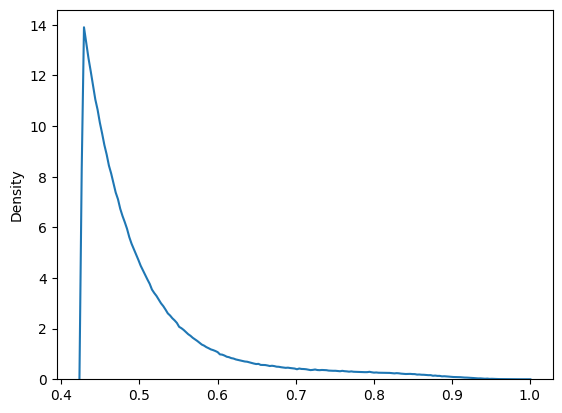

In [37]:
sns.kdeplot(sc.data, bw_method=0.01)

In [38]:
from sklearn.cluster import SpectralClustering
from scipy.sparse import csr_matrix

# Assuming 'sparse_matrix' is your scipy sparse matrix
# model = SpectralClustering(n_clusters=3, affinity='precomputed', n_init=100)
# labels = model.fit_predict(sc)

In [51]:
G = nx.from_scipy_sparse_matrix(sc)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [50]:
import networkx as nx
import community as community_louvain

partition = community_louvain.best_partition(G)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [41]:
(sc.sum(axis=1) == 0).sum()

np.int64(105)

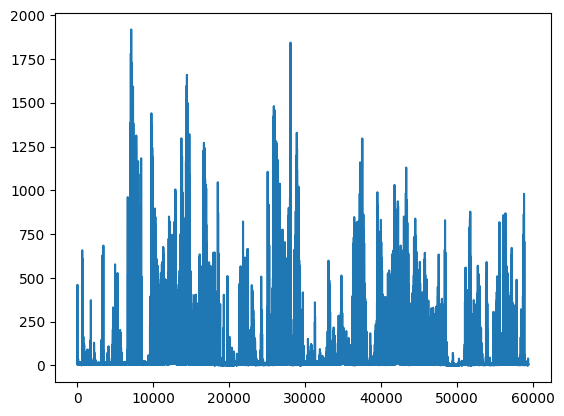

In [49]:
plt.plot(sc.getnnz(axis=0))

# Infomap

# EV Maxs

In [129]:
ev_maxs = tmt.matrix.block_analysis(voxel_data[:, :10000], tmt.matrix.ev_aggregator,
                                    device="mps", use_torch=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [56]:
(ev_maxs >= 0.5).mean() * 100

np.float64(86.18)

<Axes: ylabel='Density'>

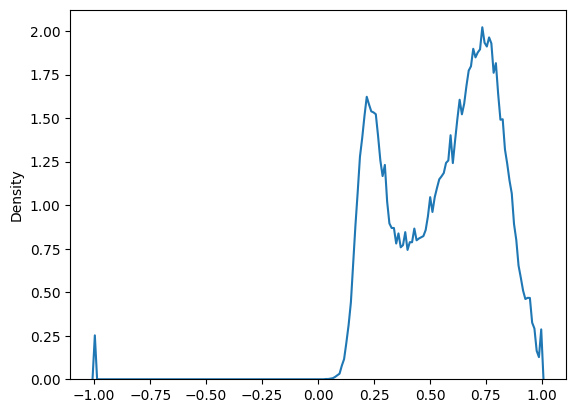

In [179]:
sns.kdeplot(ev_maxs, bw_method=0.01)

[] within parcel vs out of parcel correlations for voxel level

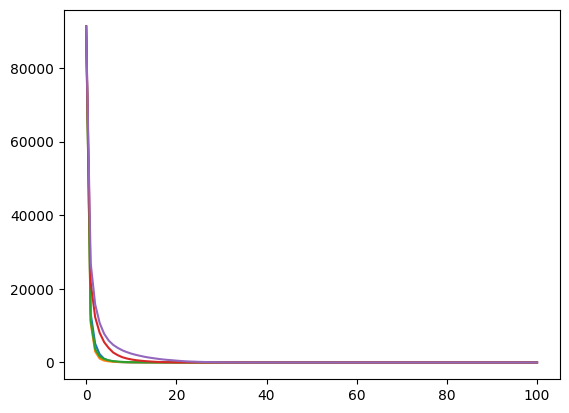

In [558]:
plt.plot(na_counts.T);

In [543]:
na_counts = {thres: [] for thres in np.linspace(0, 1, 101)}